In [1]:
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from keras_preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from transformers import BertTokenizer, TFBertForSequenceClassification
from transformers import InputExample, InputFeatures
import string
from nltk.stem import PorterStemmer
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, Bidirectional, GRU, MaxPooling1D, Conv1D, BatchNormalization, GlobalMaxPooling1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from gensim.models import Word2Vec, KeyedVectors
from keras.preprocessing.text import Tokenizer
from keras.regularizers import l2
import tensorflow as tf
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score

2024-09-17 00:28:43.386679: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /Users/erezgilat/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/erezgilat/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/erezgilat/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/erezgilat/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

Data set loading 

In [3]:
data = pd.read_csv("salafi_model_data.csv")

# Preprocessing

In [4]:
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Tokenize text
    words = text.split()
    
    # Remove stop words
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]
        
    # Stem words
    stemmer = PorterStemmer()
    words = [stemmer.stem(word) for word in words]
        
    # Lemmatize words
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]


    return ' '.join(words)

# Data Balancing

### Down sampling

In [5]:
# Separate positive and negative tweets
positive_tweets = data[data['label'] == 1]
negative_tweets = data[data['label'] == 0]
# Downsample negative tweets
negative_tweets_downsampled = negative_tweets.sample(len(positive_tweets), random_state=1)
# Combine positive tweets with downsampled negative tweets
balanced_data_undersample = pd.concat([positive_tweets, negative_tweets_downsampled])

In [6]:
data['tweet'] = data['tweet'].apply(preprocess_text)
data['label'] = data['label'].map({'Positive': 1, 'Negative': 0})

# TF-IDF MODEL 

### Over Sampling using SMOTE and TF-IDF

In [7]:
# Extract the features and labels
X = data['tweet']
y = data['label']

# Split the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=47, stratify=y)

# Apply TfidfVectorizer to the training data
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform the test data using the already fitted vectorizer
X_test_tfidf = vectorizer.transform(X_test)

# Apply SMOTE to the training data
smote = SMOTE(random_state=47)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train)

# Create a support vector classifier
svm = SVC(kernel='linear')

# Train the classifier
svm.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test data
y_pred = svm.predict(X_test_tfidf)

In [8]:
print("Test acurrecy score: ", accuracy_score(y_test, y_pred))
print("Train acurrecy score: ", accuracy_score(y_train, svm.predict(X_train_tfidf)))
print("auc:", roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
# weighted average of the precision, recall, and F1 score
print("f1_score: ", f1_score(y_test, y_pred, average='weighted'))
print("recall_score: ", recall_score(y_test, y_pred, average='weighted'))
print("precision_score: ", precision_score(y_test, y_pred, average='weighted'))


Test acurrecy score:  0.909433962264151
Train acurrecy score:  0.9826826196473551
auc: 0.8773262234822885
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       589
           1       0.83      0.81      0.82       206

    accuracy                           0.91       795
   macro avg       0.88      0.88      0.88       795
weighted avg       0.91      0.91      0.91       795

f1_score:  0.9089942298465395
recall_score:  0.909433962264151
precision_score:  0.9086833676866973


## Deep learning model using TF-IDF and over sampling positive class

Epoch 1/6
76/76 [==============================] - 5s 59ms/step - loss: 0.6909 - accuracy: 0.5450 - val_loss: 0.6914 - val_accuracy: 0.4918 - lr: 1.0000e-04
Epoch 2/6
76/76 [==============================] - 4s 55ms/step - loss: 0.6802 - accuracy: 0.6229 - val_loss: 0.6852 - val_accuracy: 0.5270 - lr: 1.0000e-04
Epoch 3/6
76/76 [==============================] - 4s 59ms/step - loss: 0.6547 - accuracy: 0.7038 - val_loss: 0.6571 - val_accuracy: 0.7509 - lr: 1.0000e-04
Epoch 4/6
76/76 [==============================] - 5s 59ms/step - loss: 0.5914 - accuracy: 0.8217 - val_loss: 0.5729 - val_accuracy: 0.8616 - lr: 1.0000e-04
Epoch 5/6
76/76 [==============================] - 5s 60ms/step - loss: 0.4787 - accuracy: 0.8833 - val_loss: 0.4526 - val_accuracy: 0.8767 - lr: 1.0000e-04
Epoch 6/6
76/76 [==============================] - 4s 56ms/step - loss: 0.3566 - accuracy: 0.9098 - val_loss: 0.3614 - val_accuracy: 0.8893 - lr: 1.0000e-04


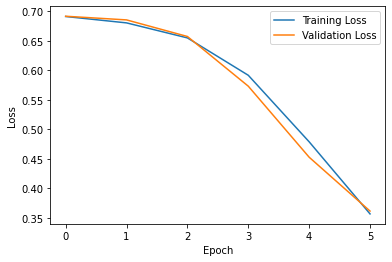

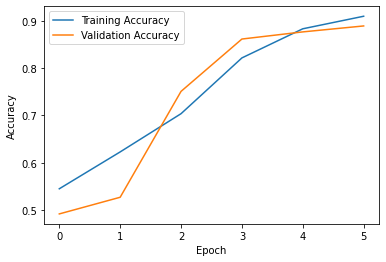

In [9]:
# Split the data into training and testing sets with stratification to two dataframes
df_train, df_test = train_test_split(data, test_size=0.2, random_state=47, stratify=data['label'])

# resampling the dummest way
df_train_positives = df_train[df_train['label'] == 1]
df_train_negatives = df_train[df_train['label'] == 0]

df_train_balanced = pd.concat([df_train_positives,df_train_positives,df_train_positives,df_train_negatives])

X_train = df_train_balanced['tweet']
y_train = df_train_balanced['label']
X_test = df_test['tweet']
y_test = df_test['label']

# Apply TfidfVectorizer to the training data
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Convert the sparse matrix to a dense matrix
X_train_tfidf = X_train_tfidf.toarray()
X_test_tfidf = X_test_tfidf.toarray()

# Define a Keras sequential model
best2 = Sequential()

# Add input layer
best2.add(Dense(512, input_shape=(X_train_tfidf.shape[1],), activation='relu'))

# Add dropout layer
best2.add(Dropout(0.7))

# Add a dense layer
best2.add(Dense(256, activation='relu'))

# Add dropout layer
best2.add(Dropout(0.7))

# Add the output layer
best2.add(Dense(1, activation='sigmoid'))

# Compile the model
best2.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Define the early stopping and learning rate reduction callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.001)

# Train the model
history = best2.fit(X_train_tfidf, y_train, validation_data=(X_test_tfidf, y_test), epochs=6, batch_size=64, callbacks=[early_stopping, reduce_lr])

# Plot the training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [10]:
# Sequantial model prediction
y_pred = best2.predict(X_test_tfidf)
y_pred = np.round(y_pred).astype(int)

y_train_pred = best2.predict(X_train_tfidf)
y_train_pred = np.round(y_train_pred).astype(int)

print("Test acurrecy score: ", accuracy_score(y_test, y_pred))
print("Train acurrecy score: ", accuracy_score(y_train, y_train_pred))
print("auc:", roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
# weighted average of the precision, recall, and F1 score
print("f1_score: ", f1_score(y_test, y_pred, average='weighted'))
print("recall_score: ", recall_score(y_test, y_pred, average='weighted'))
print("precision_score: ", precision_score(y_test, y_pred, average='weighted'))


151/151 [==============================] - 1s 3ms/step
Test acurrecy score:  0.889308176100629
Train acurrecy score:  0.9440298507462687
auc: 0.8511175762770534
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       589
           1       0.80      0.77      0.78       206

    accuracy                           0.89       795
   macro avg       0.86      0.85      0.85       795
weighted avg       0.89      0.89      0.89       795

f1_score:  0.8887707253679927
recall_score:  0.889308176100629
precision_score:  0.8883571692828074


# Word2Vec Model

Epoch 1/15
76/76 [==============================] - 6s 43ms/step - loss: 0.5567 - accuracy: 0.7079 - val_loss: 0.4569 - val_accuracy: 0.8201
Epoch 2/15
76/76 [==============================] - 3s 42ms/step - loss: 0.4513 - accuracy: 0.7898 - val_loss: 0.3849 - val_accuracy: 0.8289
Epoch 3/15
76/76 [==============================] - 3s 36ms/step - loss: 0.4254 - accuracy: 0.8002 - val_loss: 0.4350 - val_accuracy: 0.8390
Epoch 4/15
76/76 [==============================] - 3s 35ms/step - loss: 0.3916 - accuracy: 0.8199 - val_loss: 0.5515 - val_accuracy: 0.7384
Epoch 5/15
76/76 [==============================] - 3s 36ms/step - loss: 0.3792 - accuracy: 0.8342 - val_loss: 0.4135 - val_accuracy: 0.8214
Epoch 6/15
76/76 [==============================] - 3s 36ms/step - loss: 0.3616 - accuracy: 0.8367 - val_loss: 0.3350 - val_accuracy: 0.8717
Epoch 7/15
76/76 [==============================] - 3s 36ms/step - loss: 0.3471 - accuracy: 0.8476 - val_loss: 0.3614 - val_accuracy: 0.8440
Epoch 8/15
76

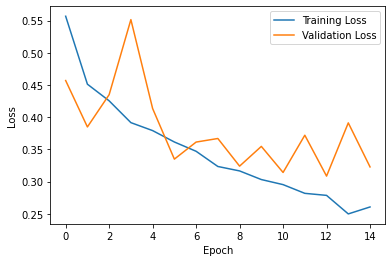

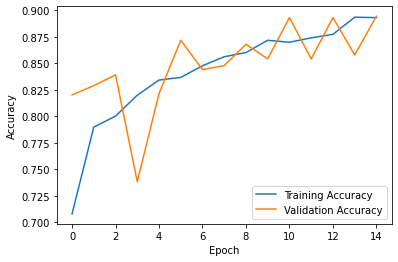

In [11]:
# Split the data into training and testing sets with stratification to two dataframes
df_train, df_test = train_test_split(data, test_size=0.2, random_state=47, stratify=data['label'])

# resampling the dummest way
df_train_positives = df_train[df_train['label'] == 1]
df_train_negatives = df_train[df_train['label'] == 0]

df_train_balanced = pd.concat([df_train_positives,df_train_positives,df_train_positives,df_train_negatives])

X_train = df_train_balanced['tweet']
y_train = df_train_balanced['label']
X_test = df_test['tweet']
y_test = df_test['label']

# Apply word tokenization
X_train_tokens = [word_tokenize(text) for text in X_train]
X_test_tokens = [word_tokenize(text) for text in X_test]

# Create Word2Vec embeddings
w2v_model = Word2Vec(sentences=X_train_tokens, vector_size=100, window=5, min_count=1, workers=4)
w2v_model.train(X_train_tokens, total_examples=len(X_train_tokens), epochs=10)

# Tokenize and pad sequences
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
vocab_size = len(tokenizer.word_index) + 1

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_sequence_length = max([len(seq) for seq in X_train_seq])

X_train_pad = pad_sequences(X_train_seq, padding='post', maxlen=max_sequence_length)
X_test_pad = pad_sequences(X_test_seq, padding='post', maxlen=max_sequence_length)

# Create an embedding matrix
embedding_matrix = np.zeros((vocab_size, 100))
for word, index in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[index] = w2v_model.wv[word]

# Build LSTM model
best1 = Sequential()
best1.add(Embedding(input_dim=vocab_size, output_dim=100, weights=[embedding_matrix], input_length=max_sequence_length, trainable=False))
best1.add(SpatialDropout1D(0.2))
best1.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
best1.add(Dense(1, activation='sigmoid'))

# Compile the model
best1.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Define the early stopping and learning rate reduction callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.0001)

# Train the model
history = best1.fit(X_train_pad, y_train, validation_data=(X_test_pad, y_test), epochs=15, batch_size=64
                    #, callbacks=[early_stopping, reduce_lr]
                    )

# Plot the training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [12]:
# Sequantial model prediction
y_pred = best1.predict(X_test_pad)
y_pred = np.round(y_pred).astype(int)

y_train_pred = best1.predict(X_train_pad)
y_train_pred = np.round(y_train_pred).astype(int)

print("Test acurrecy score: ", accuracy_score(y_test, y_pred))
print("Train acurrecy score: ", accuracy_score(y_train, y_train_pred))
print("auc:", roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
# weighted average of the precision, recall, and F1 score
print("f1_score: ", f1_score(y_test, y_pred, average='weighted'))
print("recall_score: ", recall_score(y_test, y_pred, average='weighted'))
print("precision_score: ", precision_score(y_test, y_pred, average='weighted'))


151/151 [==============================] - 1s 8ms/step
Test acurrecy score:  0.8943396226415095
Train acurrecy score:  0.9262023217247097
auc: 0.8766091944549754
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       589
           1       0.77      0.84      0.80       206

    accuracy                           0.89       795
   macro avg       0.86      0.88      0.87       795
weighted avg       0.90      0.89      0.90       795

f1_score:  0.8957313401219529
recall_score:  0.8943396226415095
precision_score:  0.8981860805981846


# Soft Voting combined algorithm

In [13]:
# Vote classifier
y_pred_prob1 = best1.predict(X_test_pad)
y_pred_prob2 = best2.predict(X_test_tfidf)

# If models output probabilities, average them
y_pred_prob_avg = (y_pred_prob1 + y_pred_prob2) / 2

# Convert averaged probabilities to binary predictions
y_pred_final = (y_pred_prob_avg > 0.5).astype(int)

print("Test acurrecy score: ", accuracy_score(y_test, y_pred_final))

# predict the training data
y_train_pred_prob1 = best1.predict(X_train_pad)
y_train_pred_prob2 = best2.predict(X_train_tfidf)

# If models output probabilities, average them
y_train_pred_prob_avg = (y_train_pred_prob1 + y_train_pred_prob2) / 2

# Convert averaged probabilities to binary predictions
y_train_pred_final = (y_train_pred_prob_avg > 0.5).astype(int)

print("Train acurrecy score: ", accuracy_score(y_train, y_train_pred_final))
print("auc:", roc_auc_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))
# weighted average of the precision, recall, and F1 score
print("f1_score: ", f1_score(y_test, y_pred, average='weighted'))
print("recall_score: ", recall_score(y_test, y_pred, average='weighted'))
print("precision_score: ", precision_score(y_test, y_pred, average='weighted'))


25/25 [==============================] - 0s 4ms/step
Test acurrecy score:  0.9081761006289308
151/151 [==============================] - 1s 3ms/step
Train acurrecy score:  0.9436152570480929
auc: 0.8875253432673447
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       589
           1       0.81      0.84      0.83       206

    accuracy                           0.91       795
   macro avg       0.88      0.89      0.88       795
weighted avg       0.91      0.91      0.91       795

f1_score:  0.8957313401219529
recall_score:  0.8943396226415095
precision_score:  0.8981860805981846


# Best model satistics 
### accuracy 0.908
### f1_score 0.896
### auc 0.88

In [14]:
# read the for_eli2.csv file and predict the labels for each content in the file
df = pd.read_csv('new list classify by Eli.csv')
df['content'] = df['content'].apply(preprocess_text)
X_test = df['content']
X_test_tfidf = vectorizer.transform(X_test)
X_test_tfidf = X_test_tfidf.toarray()
X_test_tokens = [word_tokenize(text) for text in X_test]
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_test_pad = pad_sequences(X_test_seq, padding='post', maxlen=max_sequence_length)

y_pred_prob1 = best1.predict(X_test_pad)
y_pred_prob2 = best2.predict(X_test_tfidf)

# If models output probabilities, average them
y_pred_prob_avg = (y_pred_prob1 + y_pred_prob2) / 2

# Convert averaged probabilities to binary predictions
y_pred_final = (y_pred_prob_avg > 0.5).astype(int)

df['label'] = y_pred_final

df.to_csv('new_predicted_labels.csv', index=False)


10/10 [==============================] - 0s 3ms/step
